In [1]:
import numpy as np
import matplotlib.pyplot as plt

3. Эмпирическое распределение и p-value (1 балл)
Цель: промоделировать вычисление порога для заданного уровня значимости.
----------------------------------------------------------------------------------
Задачи:
1. Напишите генератор случайных последовательностей длины L = 9 с частотами генома человека
(A/T : 0.295, G/C : 0.205).
2. Сгенерируйте 100 000 таких "фоновых"последовательностей.
3. Посчитайте скор по вашей PWM для каждой из 100 000 последовательностей.
4. Постройте гистограмму распределения скоров (используя matplotlib.pyplot.hist).
5. Напишите функцию get_pvalue(score), которая возвращает долю фоновых скоров ≥ заданного
score.
6. Найдите, какой порог (threshold) нужно установить, чтобы p-value ≈ 10−4.
-------------------------------------------------------------------------------------------------
Ответ: Код генерации и расчетов. Построенная гистограмма распределения скоров (изображение). Вы-
численное значение порога для p-value ≈ 10−4.

In [ ]:
bg_probs = np.array([0.295, 0.205, 0.205, 0.295])
N_sequences = 100000
L = 9
idx_sites = np.random.choice(4, size=(N_sequences, L), p=bg_probs)

nuc_array = np.array(['A', 'C', 'G', 'T'])


sites = nuc_array[idx_sites]

In [9]:
def build_pfm(sites):
    matrix = np.zeros((4, len(sites)))
    mapping = {'A':0, 'C': 1, 'G':2, 'T':3}
    for seq in sites:
        for i, char in enumerate(seq):
            matrix[mapping[char], i] += 1
    return matrix

In [10]:
pfm = build_pfm(sites)

In [12]:
def build_ppm(pfm, pseudocount=0.1):
    n_seq = np.sum(pfm[:, 0])
    matrix = (pfm + pseudocount)/(n_seq + 4*pseudocount)
    return matrix

In [13]:
ppm = build_ppm(pfm)

In [14]:
start_weights = {'A':0.295, 'C': 0.205, 'G':0.205, 'T':0.295}

In [16]:
def build_pwm(ppm, start_weights):
    mapping = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}
    matrix = np.zeros_like(ppm)
    for row in range(4):
        matrix[row, :] = np.log2(ppm[row, :]/start_weights[mapping[row]])
    return matrix

In [27]:
pwm = build_pwm(ppm, start_weights=start_weights)
scores = np.sum(pwm[idx_sites, np.arange(L)], axis = 1)

In [30]:
def get_pvalue(score, background_scores):
    """
    Возвращает долю фоновых скоров >= заданного score.
    score: конкретное число (скор последовательности)
    background_scores: массив из 100,000 скоров, который мы посчитали ранее
    """
    # Считаем, сколько случайных скоров оказались больше или равны нашему
    count_better_or_equal = np.sum(background_scores >= score)
    
    # Делим на общее количество (N_sequences)
    return count_better_or_equal / len(background_scores)

In [ ]:
threshold_10_4 = np.percentile(scores, 99.99)

print(f"Порог (Threshold) для p-value 10^-4: {threshold_10_4:.4f}")

calculated_p = get_pvalue(threshold_10_4, scores)
print(f"Проверка: p-value на этом пороге составляет {calculated_p:.6f}")

Порог (Threshold) для p-value 10^-4: 0.0717
Проверка: p-value на этом пороге составляет 0.000100


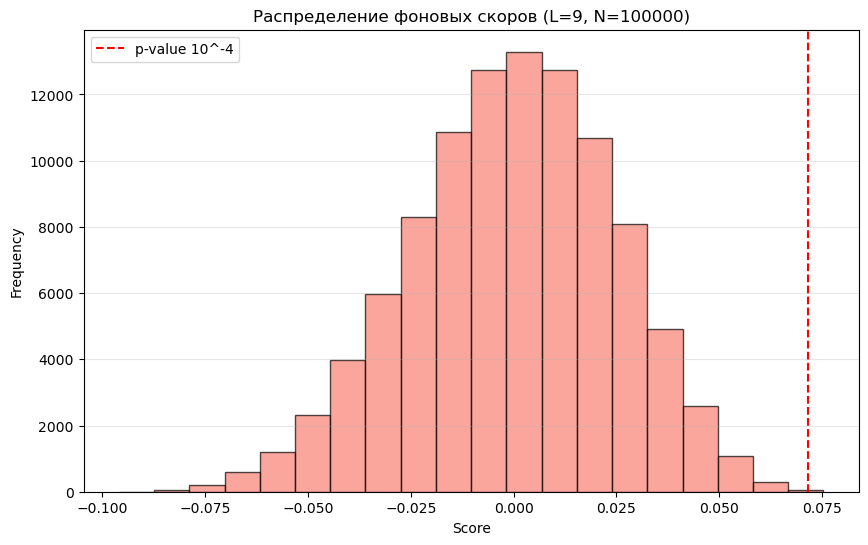

In [28]:
plt.figure(figsize=(10, 6))
plt.hist(scores, bins=20, color='salmon', edgecolor='black', alpha=0.7)
plt.axvline(np.percentile(scores, 99.99), color='red', linestyle='--', label='p-value 10^-4')
plt.title(f'Распределение фоновых скоров (L={L}, N={N_sequences})')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)